## Imports
---

In [1]:
import sys
sys.path.append("..")

import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from utils import StaticUtils

DATA_DIR = Path("../data/clean")
StaticUtils.set_plt_config()

## Data
---

In [2]:
df_ventas = pd.read_parquet(DATA_DIR / "ventas.parquet")
df_ventas.set_index("id_venta", inplace=True)

df_clientes = pd.read_parquet(DATA_DIR / "clientes.parquet")
df_clientes.set_index("id_cliente", inplace=True)

df_marketing = pd.read_parquet(DATA_DIR / "marketing.parquet")
df_marketing.set_index("id_campanha", inplace=True)

## Ventas y Marketing
---

In [3]:
# Calcular precio total (precio * cantidad)
df_ventas["precio_total"] = (
    df_ventas["precio"] * df_ventas["cantidad"]
)

# Juntar 'ventas' con 'marketing'
resumen_marketing = (
    df_marketing
    .groupby("producto")
    .agg(
        costo_total_campanhas=("costo", "sum"),
        inicio_campanha=("fecha_inicio", "min"),  # primer campaña
        fin_campanha=("fecha_fin", "max")         # última campaña
    )
    .reset_index()
)

# Duración total de campañas en días
resumen_marketing["duracion_campanha"] = (
    resumen_marketing["fin_campanha"] - resumen_marketing["inicio_campanha"]
).dt.days

ventas_marketing = (
    df_ventas
    .merge(resumen_marketing, on="producto", how="left")
)

ventas_marketing.to_parquet(DATA_DIR / "ventas_marketing.parquet", index=False)
display(ventas_marketing.head())

,producto,precio,cantidad,fecha_venta,categoria,precio_total,costo_total_campanhas,inicio_campanha,fin_campanha,duracion_campanha
0,Cuadro decorativo,69.94,5,2024-01-02,Decoración,349.70,15.85,2024-04-27,2024-12-23,240
1,Lámpara de mesa,105.10,5,2024-01-02,Decoración,525.50,15.93,2024-03-28,2024-10-07,193
2,Secadora,97.96,3,2024-01-02,Electrodomésticos,293.88,14.59,2024-07-24,2025-01-07,167
3,Heladera,114.35,8,2024-01-02,Electrodomésticos,914.80,13.11,2024-05-06,2024-08-09,95
4,Secadora,106.21,4,2024-01-02,Electrodomésticos,424.84,14.59,2024-07-24,2025-01-07,167


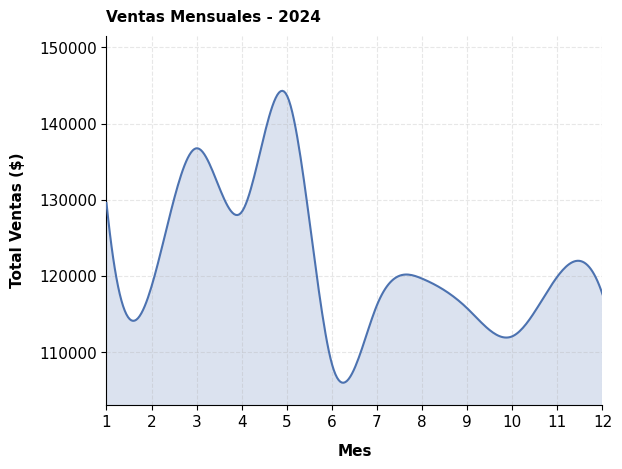

In [4]:
# Ventas mensuales

df_ventas["precio_total"] = (
    df_ventas["precio"] * df_ventas["cantidad"]
)

ventas_mensuales = (
    df_ventas
    .groupby(df_ventas["fecha_venta"].dt.month)["precio_total"]
    .sum()
)

ventas_mensuales.index.name = "mes"
ventas_mensuales.name = "total_ventas"

x_smooth, y_smooth = (
    StaticUtils.smooth_line(
        x = ventas_mensuales.index, 
        y = ventas_mensuales.values
    )
)

plt.plot(x_smooth, y_smooth, zorder=3)
plt.fill_between(x_smooth, y_smooth, alpha=0.2)
plt.xticks(ventas_mensuales.index)
plt.xlim(x_smooth.min(), x_smooth.max())
plt.ylim(bottom=ventas_mensuales.min() * 0.95)
plt.title("Ventas Mensuales - 2024", loc="left")
plt.xlabel("Mes")
plt.ylabel("Total Ventas ($)")
plt.show()

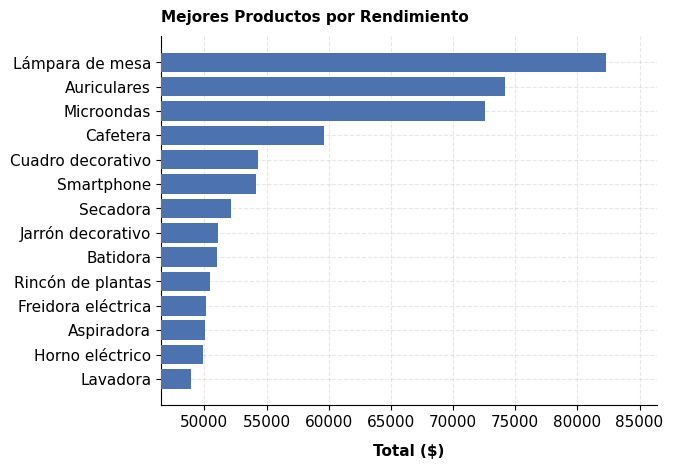

In [5]:
ventas_por_producto = (
    df_ventas
    .groupby(df_ventas["producto"], observed=True)["precio_total"]
    .sum()
)

umbral = ventas_por_producto.mean()
mejor_rendimiento = ventas_por_producto[ventas_por_producto > umbral]

mejor_rendimiento = (
    mejor_rendimiento
    .sort_values(ascending=True)
    .reset_index()
)
mejor_rendimiento.columns = ["producto", "precio_total"]

plt.barh(mejor_rendimiento["producto"], mejor_rendimiento["precio_total"], zorder=3)
plt.xlim(left=mejor_rendimiento["precio_total"].min() * 0.95)
plt.title("Mejores Productos por Rendimiento", loc="left")
plt.xlabel("Total ($)")
plt.ylabel("")
plt.show()

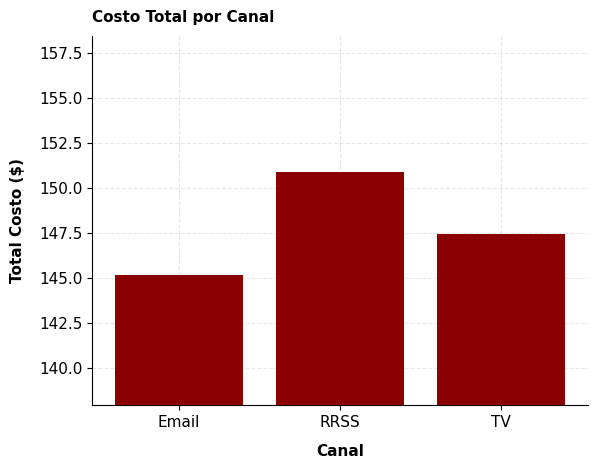

In [6]:
costo_total_por_canal = (
    df_marketing
    .reset_index()
    .groupby("canal")["costo"]
    .sum()
)

plt.bar(
    costo_total_por_canal.index, 
    costo_total_por_canal.values, 
    zorder=3, color="darkred"
)

plt.ylim(bottom=costo_total_por_canal.min() * 0.95)
plt.title("Costo Total por Canal", loc="left")
plt.xlabel("Canal")
plt.ylabel("Total Costo ($)")
plt.show()

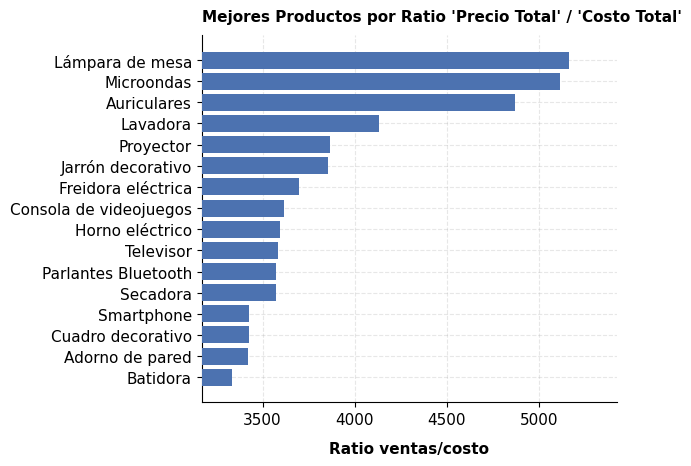

In [7]:
ratio_ventas_costo = (
    ventas_marketing
    .groupby("producto")
    .agg(
        total_ventas=("precio_total", "sum"),
        costo_total=("costo_total_campanhas", "first")
    )
    .assign(ratio=lambda df: df["total_ventas"] / df["costo_total"])
)

ratio_ordenado = (
    ratio_ventas_costo[
        ratio_ventas_costo["ratio"] > ratio_ventas_costo["ratio"]
        .mean()
    ]
    ["ratio"]
    .sort_values(ascending=True)
)

plt.barh(ratio_ordenado.index, ratio_ordenado.values, zorder=3)
plt.xlim(left=ratio_ordenado.min() * 0.95)
plt.title("Mejores Productos por Ratio 'Precio Total' / 'Costo Total'", loc="left")
plt.xlabel("Ratio ventas/costo")
plt.ylabel("")
plt.tight_layout()
plt.show()

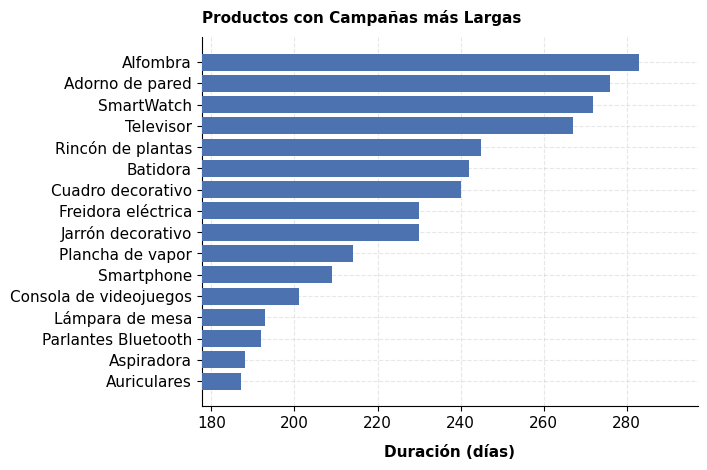

In [8]:
campanhas_mas_largas = (
    ventas_marketing
    [["producto", "duracion_campanha"]]
    .set_index("producto")
    .pipe(lambda df: df[df["duracion_campanha"] > df["duracion_campanha"].mean()])
    .sort_values("duracion_campanha", ascending=True)
)

plt.barh(campanhas_mas_largas.index, campanhas_mas_largas["duracion_campanha"], zorder=3)
plt.xlim(left=campanhas_mas_largas["duracion_campanha"].min() * 0.95)
plt.title("Productos con Campañas más Largas", loc="left")
plt.xlabel("Duración (días)")
plt.show()

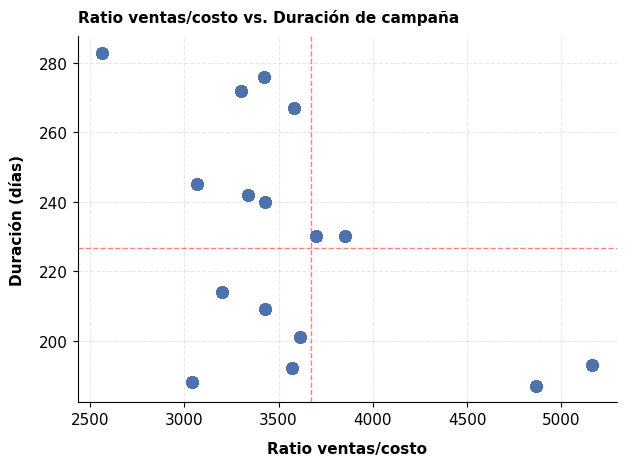

In [9]:
scatter_data = ratio_ventas_costo[["ratio"]].join(
    campanhas_mas_largas[["duracion_campanha"]], 
    how="inner"
)

fig, ax = plt.subplots()
ax.scatter(scatter_data["ratio"], scatter_data["duracion_campanha"], zorder=3, s=60)
ax.axvline(scatter_data["ratio"].mean(), color="red", linestyle="--", alpha=0.5, linewidth=1)
ax.axhline(scatter_data["duracion_campanha"].mean(), color="red", linestyle="--", alpha=0.5, linewidth=1)
ax.set_title("Ratio ventas/costo vs. Duración de campaña", loc="left")
ax.set_xlabel("Ratio ventas/costo")
ax.set_ylabel("Duración (días)")
plt.tight_layout()
plt.show()

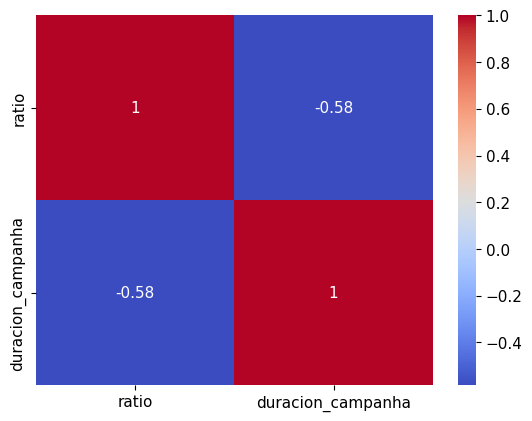

In [10]:
corr_duracion_ratio = scatter_data[["ratio", "duracion_campanha"]].corr()
sns.heatmap(corr_duracion_ratio, cmap='coolwarm', annot=True)
plt.grid(False)
plt.show()

## Clientes
---

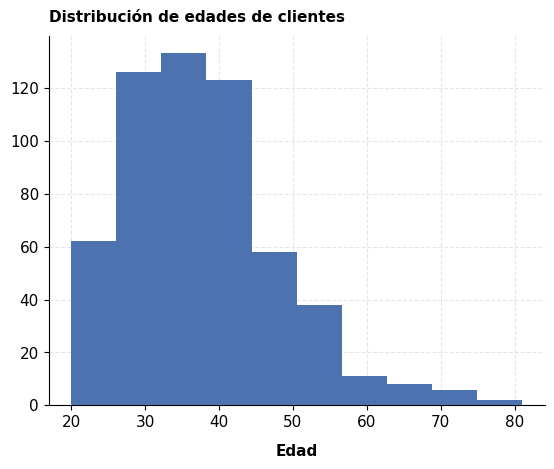

In [11]:
plt.hist(df_clientes["edad"], zorder=3)
plt.title("Distribución de edades de clientes", loc="left")
plt.xlabel("Edad")
plt.show()

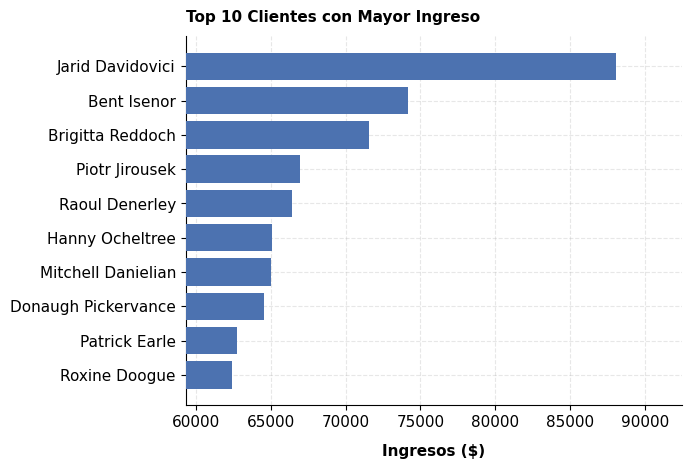

In [12]:
top10 = df_clientes.nlargest(10, columns="ingresos")
top10 = top10.sort_values(ascending=True, by="ingresos")
plt.barh(top10["nombre"], top10["ingresos"], zorder=3)
plt.xlim(left=top10["ingresos"].min() * 0.95)
plt.title("Top 10 Clientes con Mayor Ingreso", loc="left")
plt.xlabel("Ingresos ($)")
plt.show()

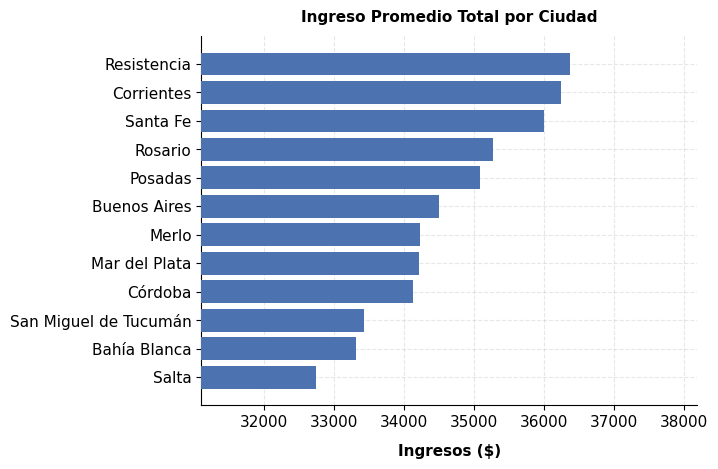

In [18]:
ingresos_por_ciudad = (
    df_clientes
    .groupby("ciudad")["ingresos"]
    .mean()
)
ingresos_por_ciudad = ingresos_por_ciudad.sort_values(ascending=True)

plt.barh(ingresos_por_ciudad.index, ingresos_por_ciudad.values, zorder=3)
plt.xlim(left=ingresos_por_ciudad.values.min() * 0.95)
plt.title("Ingreso Promedio Total por Ciudad")
plt.xlabel("Ingresos ($)")
plt.show()

## Conclusiones
---

### **Ventas y Marketing**

**1. Ventas mensuales.** El pico máximo de ventas se registra en mayo (alrededor de 144.000), seguido de una caída pronunciada hacia junio, que representa el mínimo del año (menos de $110.000). Se observan dos picos secundarios en marzo y enero. A partir de julio las ventas se estabilizan en un rango más bajo (110.000 a 122.000) respecto a la primera mitad del año, sin recuperar los niveles del primer semestre.

**2. Costos por canal de campaña.** Los tres canales presentan costos totales muy similares, con diferencias menores entre sí. RRSS es el canal más costoso (150 a 152.5), seguido por TV (147) y Email (145). La poca diferencia entre canales sugiere una inversión en marketing relativamente equilibrada, sin una apuesta clara por ninguno en particular.

**3. Mejores productos por rendimiento (umbral basado en la media).** Las lámparas de mesa lideran el ranking (con ganancias totales de más de 80.000) seguidas de los auriculares, y tercero los microondas. Si añadimos a la ecuación la variable de costo total por campañas (ratio ventas/costo), los microondas ocupan el lugar de los auriculares. De aquí para abajo, el resto de productos varían entre la ganancia total, y la ganancia total con el costo de campañas añadido.

**4. Productos con las campañas más largas.** Alfombra lidera con más de 280 días de campaña activa, seguida por Adorno de pared (alrededor de 275 días) y SmartWatch (cerca de 270 días). Todos los productos del top 4 superan los 265 días, mientras que el resto del grupo se concentra entre 180 y 240 días. Vale aclarar que la duración refleja el período entre la primera y última campaña del producto, no necesariamente que haya habido publicidad activa durante todo ese tiempo.

**5. Correlación inversa entre ratio ventas/costo y duración de campaña.** Luego de analizar ambos parámetros, se encontró que los productos con mayor duración de campaña presentaban, en general, un menor ratio ventas/costo. En el mapa de calor se observa una correlación negativa de -0.58 entre ambas variables. Una posible explicación es que los productos con campañas más largas son aquellos que necesitaron más tiempo para generar ventas; es decir, la campaña se extendió precisamente porque el producto no vendía tan bien, lo que naturalmente resulta en un ratio menor.

### **Clientes**

**1. Distribución de edades.** La distribución es asimétrica hacia la derecha, con la mayor concentración de clientes entre los 25 y 45 años. A partir de los 45 la frecuencia cae progresivamente, con muy pocos clientes mayores de 65 años. Esto sugiere que los productos apuntan a un público adulto joven, o bien que los canales de captación de clientes tienen menor alcance en personas mayores.

**2. Clientes con mayores ingresos.** Jarid Davidovici lidera con ingresos cercanos a $88.000, superando ampliamente al segundo lugar, Bent Isenor (cerca de 74.000), y al tercero, Brigitta Reddoch (cerca de 71.000). El resto del top 10 se agrupa entre 63.000 y 67.000, con diferencias menores entre ellos. Estos valores fueron identificados como outliers altos durante la limpieza y se decidió conservarlos por considerarlos posibles, aunque no puede descartarse que sean errores de carga.

**3. Ingreso promedio por ciudad.** Lo más llamativo es que las diferencias entre ciudades son relativamente pequeñas, todas se concentran entre 32.000 y 37.000, lo que sugiere una distribución bastante homogénea de ingresos en el dataset. Resistencia, Corrientes y Santa Fe lideran el promedio, lo que es contraintuitivo ya que son ciudades del Nordeste Argentino que en la realidad suelen tener indicadores económicos más bajos que Buenos Aires o Córdoba. Esto puede indicar que la muestra de clientes no es representativa de la población general; probablemente son clientes con cierto poder adquisitivo necesario para comprar los productos del catálogo.